In [ ]:
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

adata = ad.read_h5ad('../data/pcScores_split_20.h5ad')

AxisArrays with keys: X_pca_fold_1, X_pca_fold_2, X_pca_fold_3, X_pca_fold_4, X_pca_fold_5

In [64]:
from collections import Counter
def nearest_neighbors_classifier(
    adata,
    y_col='geo_region_of_origin',
    k_neighbors=400,
    label='90/10'
):
    adata = adata.copy()

    # encode classes
    classes = sorted(adata.obs[y_col].unique().tolist())
    class_dict = {c: i for i, c in enumerate(classes)}
    adata.obs['class_id'] = adata.obs[y_col].map(class_dict)


    # remove classes with too few samples
    fold_ids = sorted(list(adata.obsm.keys()))

    class_counts = adata.obs['class_id'].value_counts()
    keep_classes = class_counts[class_counts >= len(fold_ids)].index
    adata = adata[adata.obs['class_id'].isin(keep_classes)].copy()
    
    # get folds
    fold_ids = sorted(list(adata.obsm.keys()))
    adata.obs['fold_' + label] = None

    for i,fold in enumerate(fold_ids):
        # print(fold)
        fold_col = adata.obsm[fold][:,-1]
        test_mask = fold_col == 1
        train_mask = ~test_mask

        X_train = adata.obsm[fold].copy()[train_mask]
        X_test = adata.obsm[fold].copy()[test_mask]
        y_train = adata.obs.loc[train_mask, 'class_id'].to_numpy()

        # squared Euclidean distances
        dists = np.sum((X_test[:, None, :] - X_train[None, :, :]) ** 2, axis=2)

        nn_idx = np.argpartition(dists, k_neighbors - 1, axis=1)[:, :k_neighbors]

        preds = []
        for idx in nn_idx:
            labels = y_train[idx]
            preds.append(Counter(labels).most_common(1)[0][0])

        adata.obs.loc[test_mask, 'pred'] = preds
        adata.obs.loc[test_mask, 'fold_'+label] = i

    return adata
adata = nearest_neighbors_classifier(adata,k_neighbors=1)

In [88]:
from sklearn.metrics import roc_auc_score,f1_score
from tqdm.notebook import tqdm
import os


k_vals = np.arange(1,101,5)
f1s = np.zeros((4,len(k_vals),10))
split_files = sorted([f for f in os.listdir('../data/') if f.startswith('pcScores')])

for s,split_file in enumerate(split_files):
    adata = ad.read_h5ad(os.path.join('../data',split_file))
    split_no = split_file.split('.')[0][-2:]

    for j,k in tqdm(enumerate(k_vals)):
        adata_result = nearest_neighbors_classifier(adata.copy(),k_neighbors=k,label=split_no)
        region_order = adata_result.obs[['geo_region_of_origin','class_id']].drop_duplicates().sort_values(by='class_id').reset_index(drop=True)['geo_region_of_origin'].tolist()
        fold_col = "fold_"+split_no
        folds = adata_result.obs[fold_col].unique()
        fold_f1s = np.zeros(len(folds))
        for f,fold in enumerate(folds):
            y_true = adata_result[adata_result.obs[fold_col]==fold].obs['class_id'].to_numpy()
            y_pred = adata_result[adata_result.obs[fold_col]==fold].obs['pred'].to_numpy()
            f1s[s,j,f] = f1_score(y_true,y_pred,average='macro')


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

[10, 5, 4, 3]

Number of folds: [10, 5, 4, 3]


Text(0.5, 1.0, 'KNN Classification: K vs F1-Score')

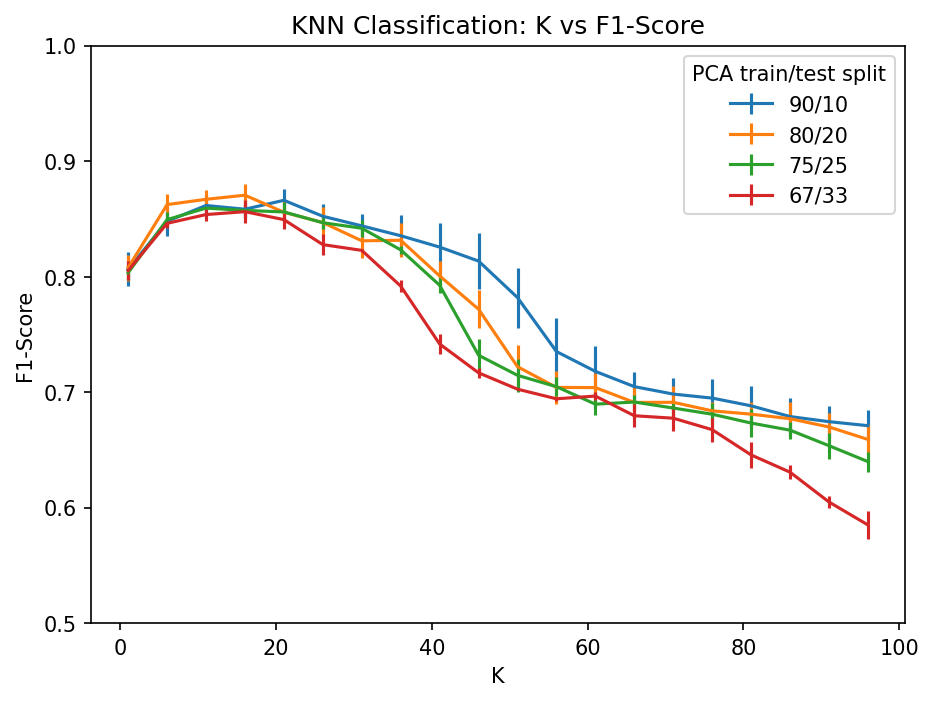

In [92]:
num_folds = [100 // int(split_file.split('.')[0][-2:]) for split_file in split_files]
print(f"Number of folds: {num_folds}")

fig,ax = plt.subplots(figsize=(7,5),dpi=150)

for i,split in enumerate(split_files):
    std_err = np.std(f1s[i,:,:num_folds[i]],axis=1) / np.sqrt(5)
    # average f1 across folds
    split_label = int(split.split('.')[0][-2:])
    split_label = f"{100-split_label}/{split_label}"
    f1_means = f1s[i,:,:num_folds[i]].mean(axis=1)
    # ax.plot(k_vals,f1_means,label=split_label)
    # ax.scatter(x=k_vals[np.argmax(f1_means)],y=f1_means.max())
    # ax.annotate(xy=(k_vals[np.argmax(f1_means)],f1_means.max()+0.01),text=f"max: {round(f1_means.max(),4)}")

    ax.errorbar(k_vals,f1_means,yerr=std_err,label=split_label)
ax.set_ylabel('F1-Score')
ax.set_xlabel('K')
ax.set_ylim([0.5,1])
ax.legend(title='PCA train/test split')

ax.set_title('KNN Classification: K vs F1-Score')

0.7843067106236592
[[0.94071146 0.         0.00790514 0.         0.         0.0513834
  0.        ]
 [0.         0.98387097 0.         0.01612903 0.         0.
  0.        ]
 [0.         0.         0.60262009 0.11353712 0.17467249 0.10917031
  0.        ]
 [0.         0.         0.         1.         0.         0.
  0.        ]
 [0.         0.         0.18791946 0.         0.63087248 0.18120805
  0.        ]
 [0.01898734 0.         0.12658228 0.00632911 0.32911392 0.51898734
  0.        ]
 [0.         0.         0.         0.         0.         0.
  1.        ]]


Text(0.5, 0.98, 'Normalized Confusion Matrix')

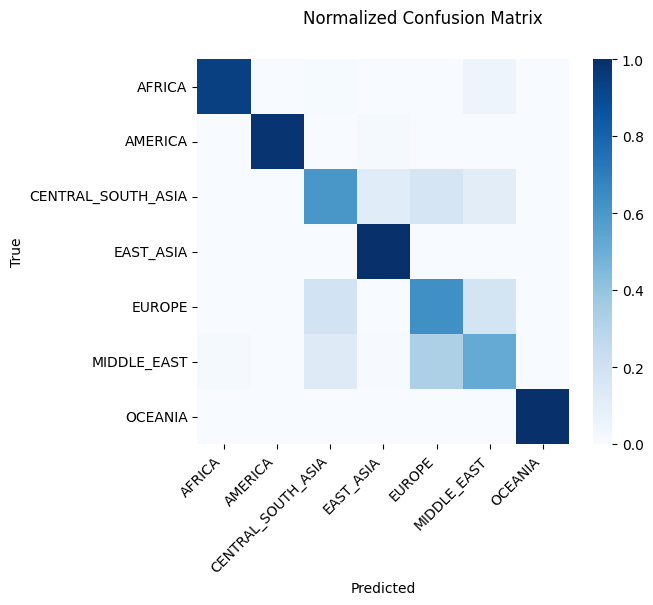

In [ ]:


# from sklearn.metrics import confusion_matrix
# region_order = adata.obs[['geo_region_of_origin','class_id']].drop_duplicates().sort_values(by='class_id').reset_index(drop=True)['geo_region_of_origin'].tolist()
# y_true = adata.obs['class_id'].to_numpy()
# y_pred = adata.obs['pred'].to_numpy()

# print(f1_score(y_true,y_pred,average='weighted'))
# cm = confusion_matrix(y_true, y_pred)

# cm_norm = cm / cm.sum(axis=1, keepdims=True)
# print(cm_norm)

# import matplotlib.pyplot as plt
# fig,ax = plt.subplots(figsize=(6,5))
# sns.heatmap(cm_norm, cmap='Blues',ax=ax)
# ax.set_xlabel("Predicted")
# ax.set_xticklabels(region_order,rotation=45,ha='right')
# ax.set_ylabel("True")
# ax.set_yticklabels(region_order,ha='right',rotation=0)
# # ax.set_xticks(ax.get_xticks()
# fig.suptitle("Normalized Confusion Matrix")
